In [117]:
import time
import datetime as dt
import numpy as np
import pandas as pd
from rivapy.optimization.models.batterystorage import BatteryStorage
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
ask_prices = np.load("./notebooks/tools/ask_prices.npy")
bid_prices = np.load("./notebooks/tools/bid_prices.npy")
dispatch = np.load("./notebooks/tools/dispatches.npy")

In [72]:
idx_array = np.where(dispatch.sum(axis=1) != 0)[0]
start_idx = idx_array[0]
start_idx

np.int64(45)

In [7]:
dispatch[start_idx,:]

array([ 0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.23765,  0.     , -0.25   ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
        0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.  

In [ ]:
eff_in = 0.97
eff_out = 0.98
#states = np.arange(0, 100.5, step=0.5, dtype=np.float32)
states = np.round(np.arange(0, 2.1, step=0.01, dtype=np.float32), 2)
#actions = np.array([-12.5, -11.5, -10.5,  -9.5,  -8.5,  -7.5,  -6.5,  -5.5,  -4.5,
        # -3.5,  -2.5,  -1.5,  -0.5,   0.5,   0.0, 1.5,   2.5,   3.5,   4.5,
        #  5.5,   6.5,   7.5,   8.5,   9.5,  10.5,  11.5,  12.5])
        
        
        
actions = np.round(np.arange(-0.25, 0.26, step=0.01, dtype=np.float32), 2)

# actions = np.array([-0.25, -0.24, -0.19, -0.18, -0.17,
#        -0.16, -0.15, -0.14, -0.13, -0.12, -0.11, -0.1 , -0.09, -0.08,
#        -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01,  0.  ,  0.01,
#         0.02,  0.03,  0.04,  0.05,  0.06,  0.07,  0.08,  0.09,  0.1 ,
#         0.11,  0.12,  0.13,  0.14,  0.15,  0.16,  0.24,  0.25], dtype=np.float32)
max_charges = np.array([0.0, 0.25, 0.5, 1.0, 1.5, 2])

#max_charges = np.array([0.0, 50.0, 100.0], dtype=np.float32)
max_capacity = 2

batterystorage = BatteryStorage(
    eff_in=eff_in, eff_out=eff_out, max_capacity=max_capacity, ask_prices=ask_prices[start_idx, :], bid_prices=bid_prices[start_idx, :], 
    max_charges=max_charges, states=states, actions=actions, precompile=True, start_state=0.5, end_state=0.5
)

TEST 1 0.0 0.0 0.0 0.0
FINAL 0.0 0.0 0.0 0.0
#########################################################################################
TEST 1 0.0 0.0 0.0 0.0
FINAL 0.0 0.0 0.0 0.0
#########################################################################################
TEST 1 0.0 0.0 0.0 0.0
FINAL 0.0 0.0 0.0 0.0
#########################################################################################
TEST 1 0.0 0.0 0.0 0.0
FINAL 0.0 0.0 0.0 0.0
#########################################################################################
TEST 1 0.0 0.0 0.0 0.0
FINAL 0.0 0.0 0.0 0.0
#########################################################################################
TEST 1 0.0 0.0 0.0 0.0
FINAL 0.0 0.0 0.0 0.0
#########################################################################################
TEST 1 0.0 0.0 0.0 0.0
FINAL 0.0 0.0 0.0 0.0
#########################################################################################
TEST 1 0.0 0.0 0.0 0.0
FINAL 0.0 0.0 0.0 0.0
##########

In [154]:
actions

array([-0.25, -0.24, -0.23, -0.22, -0.21, -0.2 , -0.19, -0.18, -0.17,
       -0.16, -0.15, -0.14, -0.13, -0.12, -0.11, -0.1 , -0.09, -0.08,
       -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01,  0.  ,  0.01,
        0.02,  0.03,  0.04,  0.05,  0.06,  0.07,  0.08,  0.09,  0.1 ,
        0.11,  0.12,  0.13,  0.14,  0.15,  0.16,  0.17,  0.18,  0.19,
        0.2 ,  0.21,  0.22,  0.23,  0.24,  0.25], dtype=float32)

In [155]:
batterystorage.optimize()

TEST 1 -976.4643777777778 0.25 -0.25 0.0
TEST 1 -937.1692967513839 0.25999999046325684 -0.23999999463558197 0.0
TEST 1 -897.8742743146046 0.26999998092651367 -0.23000000417232513 0.0
TEST 1 -858.5791930934416 0.2800000011920929 -0.2199999988079071 0.0
TEST 1 -819.2841118014533 0.2900000214576721 -0.20999999344348907 0.0
TEST 1 -779.9890893469678 0.30000001192092896 -0.20000000298023224 0.0
TEST 1 -740.6940084091054 0.3100000023841858 -0.1899999976158142 0.0
TEST 1 -701.3989858129697 0.3199999928474426 -0.18000000715255737 0.0
TEST 1 -662.1039049459323 0.32999998331069946 -0.17000000178813934 0.0
TEST 1 -622.8088237247692 0.3400000035762787 -0.1599999964237213 0.0
TEST 1 -583.5138011286335 0.3499999940395355 -0.15000000596046448 0.0
TEST 1 -544.2187199782954 0.36000001430511475 -0.14000000059604645 0.0
TEST 1 -504.92363904043305 0.3700000047683716 -0.12999999523162842 0.0
TEST 1 -465.6285873088466 0.3799999952316284 -0.11999999731779099 0.0
TEST 1 -426.33353557726014 0.38999998569488525

In [152]:
batterystorage_output = batterystorage.create_output()
batterystorage_output

5.912122011184692


,Bid Price,Ask Price,SOC,ChargeCycle,Charging,Value
0,-4000.0,4000.0,0.5,0.0,0.0,0.0
1,-4000.0,4000.0,0.5,0.0,0.0,0.0
2,-4000.0,4000.0,0.5,0.0,0.0,0.0
3,-4000.0,4000.0,0.5,0.0,0.0,0.0
4,-4000.0,4000.0,0.5,0.0,0.0,0.0
...,...,...,...,...,...,...
91,-4000.0,4000.0,0.0,0.0,0.0,0.0
92,-4000.0,4000.0,0.0,0.0,0.0,0.0
93,-4000.0,4000.0,0.0,0.0,0.0,0.0
94,-4000.0,4000.0,0.0,0.0,0.0,0.0


In [122]:
discharge = 0.23999999463558197
discharge_price = 14.431111111111111
discharge*discharge_price*eff_out

3.463466589252154

In [123]:
charge = 0.2474226951599121
charge_price = 9.72
charge*charge_price

2.404948596954346

In [124]:
discharge*discharge_price*eff_out - charge*charge_price

1.058517992297808

In [148]:
discharge = 0.25*eff_in
discharge_price = 14.431111111111111
charge = 0.25
charge_price = 9.72
discharge*discharge_price*eff_out - charge*charge_price

0.999553555555555

In [136]:
0.25*eff_in

0.2425

In [104]:
discharge = 0.24*eff_in
discharge_price = 14.431111111111111
charge = 0.24
charge_price = 9.72
discharge*discharge_price*eff_out - charge*charge_price

1.026762666666666

In [100]:
batterystorage._value_matrix[-1,...]

array([[-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [ 0.e+00,  0.e+00,  0.e+00,  0.e+00,  0.e+00,  0.e+00],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12],
       [-1.e+12, -1.e+12, -1.e+12, -1.e+12, -1.e+12, -1

In [64]:
batterystorage._objective

array([ 0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  2.8862224,  0.       , -2.0041237,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.    

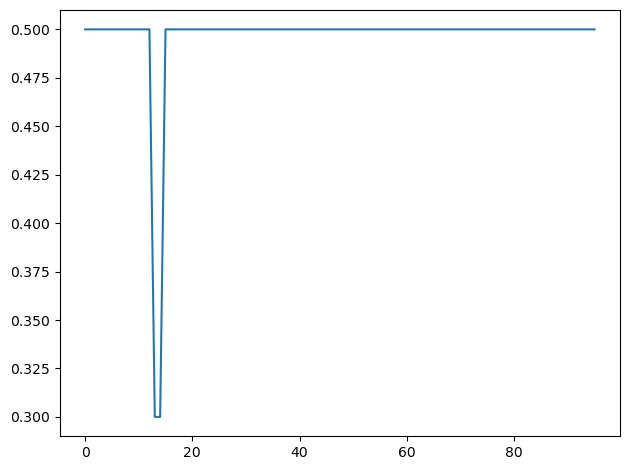

In [39]:
plt.plot(batterystorage_output['SOC'])
plt.tight_layout()